In [1]:
from sklearn.datasets import make_moons, make_blobs
import matplotlib.pyplot as plt
from autograd import mlp, Value



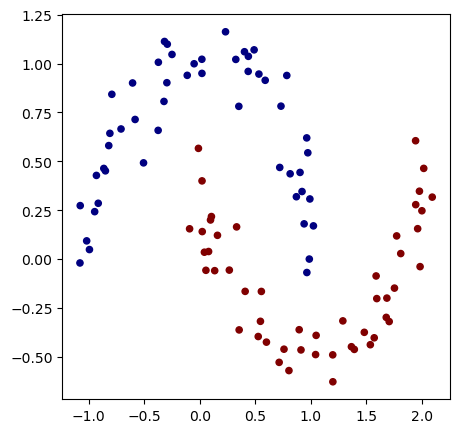

In [2]:
X, y = make_moons(n_samples=100, noise = 0.1)

y = y * 2 - 1
plt.figure(figsize=(5, 5))
plt.scatter(X[:,0], X[:,1], c=y, s=20, cmap='jet')

In [3]:
print(X)

[[ 1.96429270e+00  1.55508110e-01]
 [ 1.75512844e+00 -1.48417408e-01]
 [-7.92135978e-01  8.42891669e-01]
 [-2.96128775e-01  9.02192065e-01]
 [ 1.19884451e+00 -4.89790231e-01]
 [ 8.96405837e-01 -3.61244244e-01]
 [ 1.57268432e+00 -4.02560618e-01]
 [-8.50173561e-01  4.51399913e-01]
 [ 9.74175419e-01  5.43725579e-01]
 [ 5.90109811e-01  9.14501405e-01]
 [-3.22240784e-01  8.06433550e-01]
 [ 4.03295266e-01  1.06062099e+00]
 [ 4.38277658e-01  1.03703419e+00]
 [-9.31271246e-01  4.28004333e-01]
 [-1.07716800e+00  2.73529240e-01]
 [ 9.22040367e-01  3.45647356e-01]
 [ 1.36720993e+00 -4.48189555e-01]
 [ 1.39331600e+00 -4.61896974e-01]
 [ 2.26245144e-02  1.40692167e-01]
 [ 3.52445705e-01  7.81328601e-01]
 [-3.17485155e-01  1.11313158e+00]
 [ 4.20203096e-02  3.52024332e-02]
 [ 9.92754526e-01  3.07562982e-01]
 [ 1.81181208e+00  2.82823916e-02]
 [ 1.98023715e+00  3.47220100e-01]
 [-9.94078958e-01  4.87514874e-02]
 [ 9.64404265e-01  6.19911839e-01]
 [ 9.40884982e-01  1.80252748e-01]
 [ 1.58972297e+00 -8

In [4]:
print(y)

[ 1  1 -1 -1  1  1  1 -1 -1 -1 -1 -1 -1 -1 -1 -1  1  1  1 -1 -1  1 -1  1
  1 -1 -1 -1  1  1 -1  1 -1 -1  1 -1 -1  1 -1 -1  1 -1  1  1 -1 -1  1 -1
 -1  1 -1 -1  1  1 -1  1  1 -1  1 -1  1  1 -1  1  1  1 -1  1  1 -1  1  1
  1  1 -1  1 -1 -1 -1 -1 -1  1 -1  1  1  1  1 -1  1  1 -1 -1  1  1 -1  1
  1  1 -1 -1]


In [10]:
# model initialization
model = mlp(2, [16, 16, 1], ['ReLU', 'ReLU', 'Linear'])

In [11]:
model(X[1])[0].data

1.2703029027114283

In [12]:
def loss(pred, expected):
    # sum of squared differences
    loss = Value(0.0)
    for xi, yi in zip(pred, expected):
        loss += (xi - yi)*(xi - yi)
    mean = loss / Value(float(len(pred)))

    return mean

In [13]:
for k in range(20):

    model.zero_grad()
    pred = []
    for xi in X:
        pred.append(model(xi)[0])
    expected = [Value(float(yi)) for yi in y]
    
    cur_loss = loss(pred, expected)
    print(f'loss: {cur_loss.data}')

    # backward
    cur_loss.backward()

    #update
    learning_rate = 0.05
    for p in model.parameters():
        p.data -= p.grad * learning_rate

loss: 1.729266771488887
loss: 1.1720546750732033
loss: 0.8814289889655988
loss: 0.72796884822499
loss: 0.6399795089436063
loss: 0.5911162217439763
loss: 0.5579528558185257
loss: 0.5318235337548259
loss: 0.5096565802255586
loss: 0.48977035989569856
loss: 0.47217484068759624
loss: 0.4561307193052502
loss: 0.44257540847098
loss: 0.43073765499718425
loss: 0.42077170005745146
loss: 0.41175041208616037
loss: 0.40362189427402745
loss: 0.3961147150494416
loss: 0.38983530539754374
loss: 0.3840191309410084


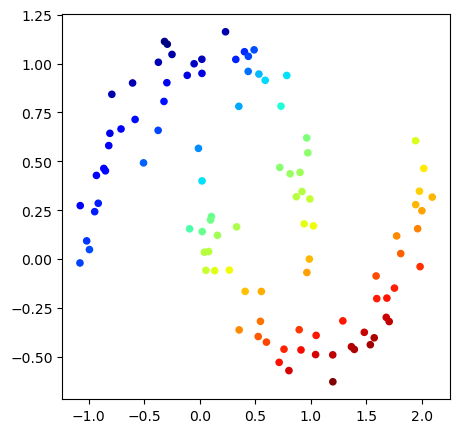

In [14]:
# Plotting prediction

pred = [v.data for v in [model(x)[0] for x in X]]

plt.figure(figsize=(5, 5))
plt.scatter(X[:,0], X[:,1], c=pred, s=20, cmap='jet')

# Sanity checks that the gradient is actually working

In [ ]:
def predict_all(model):
    model.zero_grad()
    pred = [model(xi)[0] for xi in X]
    return pred

In [20]:
def gradient_check(model):
    expected = [Value(float(yi)) for yi in y]

    fixed_parameter = model.parameters()[0]

    eps = 0.3

    fixed_parameter.data += eps

    pred = predict_all(model)
    lg = loss(pred, expected)

    fixed_parameter.data -= eps * 2

    pred = predict_all(model)
    ll = loss(pred, expected)

    change = (lg.data - ll.data) / 2 * eps

    fixed_parameter.data += eps

    real_loss = loss(predict_all(model), expected)
    real_loss.backward()

    print(f'Calculated gradient: {fixed_parameter.grad}, approximation expected: {change}')







## Model with just one neuron

In [81]:
one_neuron = mlp(2, [1], ['Linear'])
gradient_check(one_neuron)

Calculated gradient: -1.974320956648492, approximation expected: -0.17768888609836422


In [80]:
small_mlp = mlp(2, [2, 1], ['ReLU', 'Linear'])
gradient_check(small_mlp)

Calculated gradient: -0.002039264518032327, approximation expected: -0.00018655719406087678


## Overfitting check

The network should be able to memorize examples

In [72]:
big_mlp = mlp(2, [16, 16, 8, 1], ['ReLU', 'ReLU', 'ReLU', 'Linear'])

for k in range(100):

    big_mlp.zero_grad()
    pred = []
    for xi in X[0:2]:
        pred.append(model(xi)[0])
    expected = [Value(float(yi)) for yi in y]
    
    cur_loss = loss(pred, expected)
    print(f'loss: {cur_loss.data}')

    # backward
    cur_loss.backward()

    #update
    learning_rate = 0.00003
    for p in model.parameters():
        p.data -= p.grad * learning_rate

loss: 0.11430467689010204
loss: 0.1207132744223924
loss: 0.12735362612210302
loss: 0.1342187381729553
loss: 0.1413013758208705
loss: 0.14859407112912654
loss: 0.15608913098349136
loss: 0.1637786453387571
loss: 0.17165449569782884
loss: 0.1797083638142854
loss: 0.18793174060907517
loss: 0.196315935291792
loss: 0.20485208467675342
loss: 0.21353116268389233
loss: 0.22234399001427796
loss: 0.2312812439898878
loss: 0.24033346854709867
loss: 0.24949108437315595
loss: 0.25874439917478465
loss: 0.2680836180679132
loss: 0.2774988540773768
loss: 0.2869801387353495
loss: 0.2965174327671382
loss: 0.30610063685288197
loss: 0.3157196024536248
loss: 0.3253641426901537
loss: 0.3350240432629327
loss: 0.34468907340144117
loss: 0.3543489968311625
loss: 0.3639935827464794
loss: 0.37361261677769886
loss: 0.38319591194046604
loss: 0.39273331955581126
loss: 0.4022147401291412
loss: 0.4116301341764932
loss: 0.4209695329864689
loss: 0.43022304930627864
loss: 0.4393808879404788
loss: 0.4484333562510074
loss: 0.